# Heads Up - Data Understanding & Exploratory Data Analysis

**Dataset:** DataCo Smart Supply Chain for Big Data Analysis (180,519 rows × 53 columns)
**Primary lens:** Late delivery risk (binary classification)
**Secondary lens:** Shipment prioritisation (risk × order value)

---

## Purpose of this notebook

This is the consolidated with data understanding and exploratory data analysis. It answers every question needed before preprocessing begins - what the data actually contains, whether the target variable can be trusted, what signal exists in the features, and what data quality issues need to be handled.

**This notebook works through, in order:**
1. Schema overview and data dictionary
2. Unit of analysis (order level vs. order line level)
3. Missing values and duplicate audit
4. Target variable audit (`Late_delivery_risk` vs. `Delivery Status`)
5. Target class balance
6. Geographic delay patterns
7. Temporal delay patterns
8. Shipping mode and product category patterns
9. Numeric feature distributions and outliers
10. Final leakage field classification
11. EDA summary and decisions carried forward to next stage

Every section states what we found and why it matters for the next stage - this notebook is written as the actual submitted record of our reasoning, not a scratch exploration.


## Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_PATH = Path('../data/raw data/DataCoSupplyChainDataset.csv')  


**Note on encoding:** this dataset contains special characters (accented city/customer names) that break under strict UTF-8 decoding - we fall back to `ISO-8859-1`, the standard workaround for this specific dataset.

In [4]:
try:
    df = pd.read_csv(DATA_PATH, encoding='utf-8')
except UnicodeDecodeError:
    print("UTF-8 failed, falling back to ISO-8859-1")
    df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


UTF-8 failed, falling back to ISO-8859-1
Shape: 180,519 rows x 53 columns


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


## 1. Schema overview & data dictionary

In [5]:
schema_overview = pd.DataFrame({
    'column': df.columns,
    'dtype': df.dtypes.astype(str).values,
    'n_unique': [df[c].nunique() for c in df.columns],
    'n_missing': df.isnull().sum().values,
    'pct_missing': (df.isnull().sum().values / len(df) * 100).round(2),
    'sample_value': [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
})
schema_overview.sort_values('pct_missing', ascending=False)


,column,dtype,n_unique,n_missing,pct_missing,sample_value
46,Product Description,float64,0,180519,100.00,None
43,Order Zipcode,float64,609,155679,86.24,99301.0
2,Days for shipment (scheduled),int64,4,0,0.00,4
1,Days for shipping (real),int64,7,0,0.00,3
0,Type,object,4,0,0.00,DEBIT
5,Delivery Status,object,4,0,0.00,Advance shipping
6,Late_delivery_risk,int64,2,0,0.00,0
7,Category Id,int64,51,0,0.00,73
8,Category Name,object,50,0,0.00,Sporting Goods
9,Customer City,object,563,0,0.00,Caguas


**What we found:**

- Confirmed 180,519 rows × 53 columns - the correct, complete dataset.
- **`Product Description` is 100% missing** across every row. It carries zero information and will be **dropped** in Stage 3 - nothing to impute.
- **`Order Zipcode` is 86.24% missing**, and this looks systemic rather than random - very likely tied to which country an order shipped to, since zip codes don't universally apply. To be confirmed in Stage 3 (`groupby('Order Country')`), then either dropped or kept as a binary "zipcode known" indicator.
- `Customer Lname` (8 missing) and `Customer Zipcode` (3 missing) are negligible - trivial to drop or impute.
- Every other column is fully populated - this dataset is otherwise very clean, so Stage 3's imputation workload is minimal and targeted rather than broad.
- **Data quality finding worth flagging in our report:** `Customer Country` has only 2 unique values (Puerto Rico, US), while `Order Country` has 164 and `Order City` has 3,597 - the customer master records are synthetic/limited even though orders ship globally. All geographic feature engineering will use `Order Country`/`Order Region`/`Order City`, not `Customer Country`.
- Minor item to double check in Stage 3: `Category Id` has 51 unique values but `Category Name` has only 50 — worth a quick `groupby` check before relying on category names for feature engineering.
- `order date (DateOrders)` is stored as text, not a real datetime - parsed explicitly in Section 7 below.

**Order time safe input candidates:** `Type`, `Days for shipment (scheduled)`, `Shipping Mode`, `Order Region`, `Order Country`, `Order City`, `Order State`, `Category Id`, `Category Name`, `Order Item Quantity`, `Order Item Product Price`, `Sales`, `Customer Segment`, `order date (DateOrders)`.

**Post outcome fields - excluded from model inputs:** `Delivery Status`, `Late_delivery_risk` (target, not a feature), `Days for shipping (real)`, `shipping date (DateOrders)`.


## 2. Unit of analysis

In [6]:
n_rows = len(df)
n_unique_orders = df['Order Id'].nunique()
n_unique_order_items = df['Order Item Id'].nunique() if 'Order Item Id' in df.columns else None

print(f"Total rows: {n_rows:,}")
print(f"Unique Order Id values: {n_unique_orders:,}")
if n_unique_order_items:
    print(f"Unique Order Item Id values: {n_unique_order_items:,}")

avg_lines_per_order = n_rows / n_unique_orders
print(f"\nAverage lines per order: {avg_lines_per_order:.2f}")


Total rows: 180,519
Unique Order Id values: 65,752
Unique Order Item Id values: 180,519

Average lines per order: 2.75


In [7]:
sample_order_id = df['Order Id'].value_counts().index[0]
display(df[df['Order Id'] == sample_order_id][['Order Id', 'Delivery Status', 'Late_delivery_risk', 'Sales', 'Order Item Quantity', 'Order Item Product Price']])


,Order Id,Delivery Status,Late_delivery_risk,Sales,Order Item Quantity,Order Item Product Price
90419,50290,Late delivery,1,129.990005,1,129.990005
90420,50290,Late delivery,1,129.990005,1,129.990005
90422,50290,Late delivery,1,129.990005,1,129.990005
91680,50290,Late delivery,1,179.970001,3,59.990002
111298,50290,Late delivery,1,149.940002,3,49.980000


**What we found:**

- **The dataset is at order line level, not order level.** 180,519 rows collapse to **65,752 unique orders** - an average of **2.75 line items per order**. This is one of our two originally open project framing questions, now resolved: **aggregation to order level is required in Stage 3** before treating this as a one prediction per order classification problem.
- **Good news from inspecting a sample order:** `Delivery Status` and `Late_delivery_risk` are identical across every line item within the same order. Delivery outcome is genuinely an order level property in this dataset, so the target aggregates cleanly with `.groupby('Order Id')['Late_delivery_risk'].first()`.
- **Numeric fields genuinely vary across line items** within the same order (prices, quantities, sales). Stage 3 needs an explicit per column aggregation rule - sum for order value fields (`Sales`, `Order Item Quantity`), first/mode for order level categoricals (`Shipping Mode`, `Order Region`), first for the target.

**Decision to log:** aggregation rule per column, confirmed before Stage 3 begins.


## 3. Missing values and duplicate audit

In [8]:
missing_summary = schema_overview[schema_overview['n_missing'] > 0].sort_values('pct_missing', ascending=False)
missing_summary[['column', 'n_missing', 'pct_missing']]


,column,n_missing,pct_missing
46,Product Description,180519,100.00
43,Order Zipcode,155679,86.24
19,Customer Zipcode,3,0.00
14,Customer Lname,8,0.00


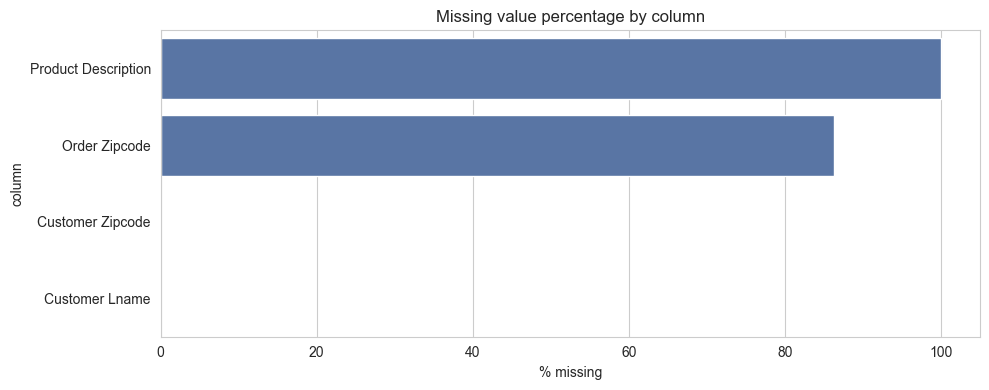

In [9]:
plt.figure(figsize=(10, max(4, len(missing_summary) * 0.3)))
sns.barplot(data=missing_summary, y='column', x='pct_missing', color='#4C72B0')
plt.xlabel('% missing')
plt.title('Missing value percentage by column')
plt.tight_layout()
plt.show()


In [11]:
n_exact_duplicates = df.duplicated().sum()
n_duplicate_order_ids = df['Order Id'].duplicated().sum()

print(f"Exact duplicate rows: {n_exact_duplicates}")
print(f"Duplicate Order Ids: {n_duplicate_order_ids} (expected - confirms order line level structure from Section 2)")


Exact duplicate rows: 0
Duplicate Order Ids: 114767 (expected - confirms order line level structure from Section 2)


**What we found:**

- **Only 4 columns have any missing values at all** - `Product Description` (100%, drop entirely), `Order Zipcode` (86.24%, likely systemic - check against `Order Country`), and two negligible cases (`Customer Lname`: 8 rows, `Customer Zipcode`: 3 rows).
- **Zero exact duplicate rows** in the entire dataset - no general de duplication step needed.
- **114,767 duplicate `Order Id` values, and this is expected, not a data quality problem** - it's simply arithmetic confirmation of the order line level structure already established in Section 2.

**Bottom line for Stage 3:** minimal imputation workload - drop one column outright, verify then handle one systemically missing column, trivially handle the rest.


## 4. Target variable audit - `Late_delivery_risk` vs. `Delivery Status`

We do not trust the precomputed `Late_delivery_risk` column blindly - we cross check it against the more granular `Delivery Status` field, particularly how `Shipping canceled` orders are coded.


In [12]:
print("Delivery Status value counts:")
print(df['Delivery Status'].value_counts())
print("\nLate_delivery_risk value counts:")
print(df['Late_delivery_risk'].value_counts())


Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64


In [13]:
audit_table = pd.crosstab(df['Delivery Status'], df['Late_delivery_risk'], margins=True)
audit_table


Late_delivery_risk,0,1,All
Delivery Status,,,
Advance shipping,41592,0,41592
Late delivery,0,98977,98977
Shipping canceled,7754,0,7754
Shipping on time,32196,0,32196
All,81542,98977,180519


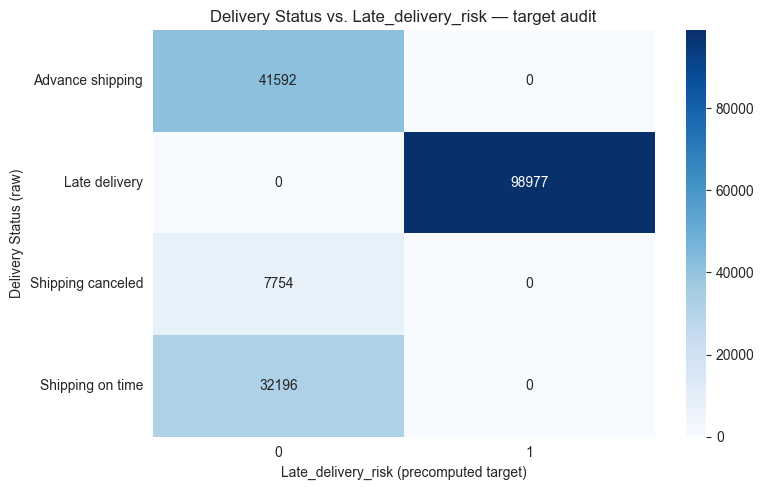

In [14]:
plt.figure(figsize=(8, 5))
sns.heatmap(pd.crosstab(df['Delivery Status'], df['Late_delivery_risk']), annot=True, fmt='d', cmap='Blues')
plt.title('Delivery Status vs. Late_delivery_risk — target audit')
plt.ylabel('Delivery Status (raw)')
plt.xlabel('Late_delivery_risk (precomputed target)')
plt.tight_layout()
plt.show()


**What we found:**

The audit is completely clean - every `Delivery Status` category maps to exactly one `Late_delivery_risk` value, with zero mixing:

| `Delivery Status` | Count | `Late_delivery_risk` |
|---|---|---|
| Advance shipping | 41,592 | 0 |
| Shipping on time | 32,196 | 0 |
| **Shipping canceled** | **7,754** | **0** |
| Late delivery | 98,977 | 1 |

We can trust `Late_delivery_risk` directly as our target - this audit stands as documented evidence that we checked rather than assumed.

**The one genuine judgement call this surfaces:** `Shipping canceled` (7,754 orders, ~4.3%) is bucketed as 0 - the same as a successful on time delivery, even though a canceled order is arguably a different kind of failure, not a success.

**Decision, logged:** we keep `Late_delivery_risk` as is (Option A of three considered - keep as is / exclude canceled orders from training / flag canceled separately in the recommendation). This is the simplest, most defensible choice, and is now evidence backed rather than a silent default, since we can state precisely how canceled orders are handled and why.


## 5. Target class balance

Class counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Class percentages:
Late_delivery_risk
1    54.83
0    45.17
Name: proportion, dtype: float64


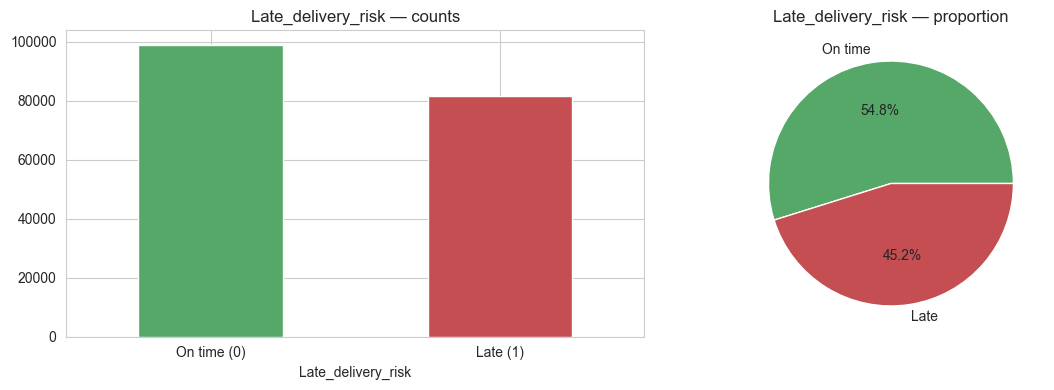

In [15]:
class_counts = df['Late_delivery_risk'].value_counts()
class_pct = df['Late_delivery_risk'].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_pct.round(2))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot(kind='bar', ax=ax[0], color=['#55A868', '#C44E52'])
ax[0].set_title('Late_delivery_risk — counts')
ax[0].set_xticklabels(['On time (0)', 'Late (1)'], rotation=0)

ax[1].pie(class_pct, labels=['On time', 'Late'], autopct='%1.1f%%', colors=['#55A868', '#C44E52'])
ax[1].set_title('Late_delivery_risk — proportion')
plt.tight_layout()
plt.show()


**What we found:**

**98,977 late (54.83%) vs. 81,542 not-late (45.17%)** - close to balanced, confirmed directly on our own extracted data.

**Implication for Stage 7 evaluation:** no aggressive imbalance handling techniques (SMOTE, heavy class weighting) are needed. **We still prioritise Recall as our primary metric - but the justification is precise: it's a cost sensitivity argument, not an imbalance argument.** Missing a late delivery (false negative) costs the business more than a false alarm (false positive) - a missed at risk shipment means no intervention happens, while a false alarm just means someone briefly checked an order that turned out fine.


## 6. Geographic delay patterns

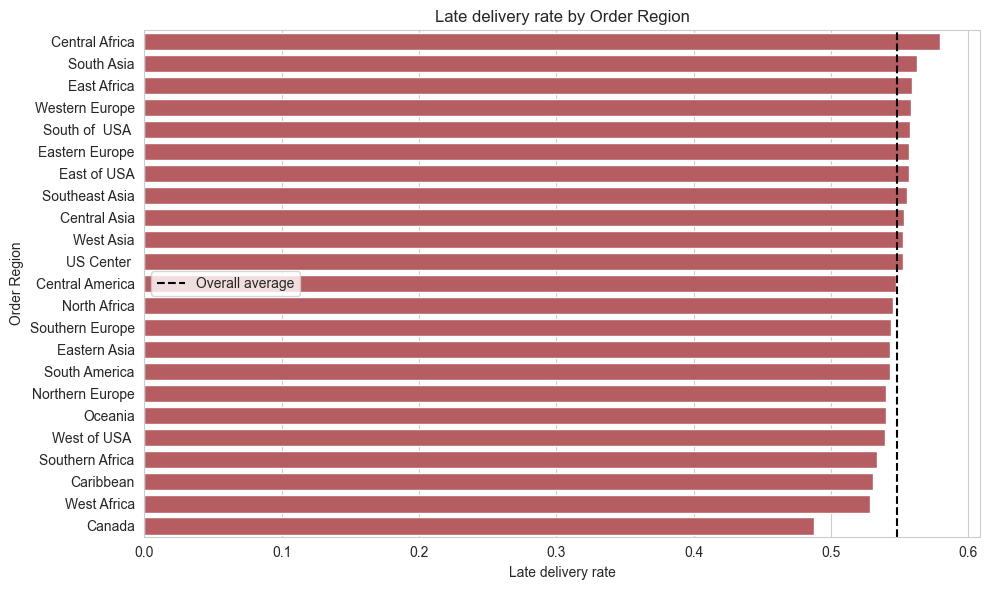

,Order Region,late_rate,n_orders
2,Central Africa,0.579606,1677
13,South Asia,0.562670,7731
5,East Africa,0.559395,1852
22,Western Europe,0.558486,27109
14,South of USA,0.557726,4045
8,Eastern Europe,0.556633,3920
6,East of USA,0.556616,6915
15,Southeast Asia,0.555299,9539
4,Central Asia,0.553345,553
20,West Asia,0.552837,6009


In [16]:
region_delay = df.groupby('Order Region')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
region_delay.columns = ['Order Region', 'late_rate', 'n_orders']
region_delay = region_delay.sort_values('late_rate', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=region_delay, y='Order Region', x='late_rate', color='#C44E52')
plt.axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.xlabel('Late delivery rate')
plt.title('Late delivery rate by Order Region')
plt.legend()
plt.tight_layout()
plt.show()

region_delay


In [18]:
country_delay = df.groupby('Order Country')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
country_delay.columns = ['Order Country', 'late_rate', 'n_orders']
country_delay_filtered = country_delay[country_delay['n_orders'] >= 100].sort_values('late_rate', ascending=False)

print("Top 10 highest late rate countries (min. 100 orders):")
display(country_delay_filtered.head(10))
print("\nTop 10 lowest late rate countries (min. 100 orders):")
display(country_delay_filtered.tail(10))


Top 10 highest late rate countries (min. 100 orders):


,Order Country,late_rate,n_orders
40,Ecuador,0.670068,294
100,Mozambique,0.639344,244
109,Níger,0.638889,108
135,Somalia,0.638298,141
68,Hungría,0.625698,179
92,Malasia,0.612132,544
36,Costa de Marfil,0.607004,257
72,Irlanda,0.606925,491
56,Ghana,0.606061,264
26,Camboya,0.605263,152



Top 10 lowest late rate countries (min. 100 orders):


,Order Country,late_rate,n_orders
91,Madagascar,0.496644,149
118,Portugal,0.492711,343
28,Canada,0.488008,959
80,Kenia,0.487395,238
52,Finlandia,0.479310,290
86,Libia,0.466667,105
39,Dinamarca,0.449123,285
130,Senegal,0.441065,263
27,Camerún,0.440000,275
149,Togo,0.368852,122


**What we found:**

- **Region level spread is fairly narrow**: 48.8% (Canada, lowest) to 58.0% (Central Africa, highest) - about 9 percentage points around the 54.8% average. `Order Region` alone is a moderate, not dominant, predictor.
- **Country level spread is much wider**: Ecuador at 67.0% (highest) down to Togo at 36.9% (lowest), roughly 30 percentage points. `Order Country` carries meaningfully more granular signal - a strong candidate for a target encoded feature in Stage 4. **Caveat:** some standout countries (e.g. Togo, n=122) are close to our 100 order filtering threshold, so these specific rates should be treated as indicative rather than fully certain.
- **Data quality finding:** `Order Country` values are inconsistently localized - some in English, others in Spanish (Hungría, Malasia, Irlanda, Camboya, "Costa de Marfil" for Ivory Coast). This needs standardisation in Stage 3 before encoding, and we should check whether any country is accidentally split across two spellings.
- **Responsible AI flag:** Central Africa, South Asia, and East Africa show the highest regional late rates. In our final recommendation, region linked risk should inform *proactive logistics support* to those regions, not be used as grounds to deprioritise service - this is the responsible AI check planned from the outset, now grounded in a real finding.

**Decisions to log:** country level delay rate prioritised over region level as a feature candidate; country name standardisation required before Stage 4 encoding.


## 7. Temporal delay patterns

In [19]:
date_col_candidates = [c for c in df.columns if 'order date' in c.lower()]
order_date_col = date_col_candidates[0]

df['order_datetime'] = pd.to_datetime(df[order_date_col], errors='coerce')
df['order_year'] = df['order_datetime'].dt.year
df['order_month'] = df['order_datetime'].dt.month
df['order_dayofweek'] = df['order_datetime'].dt.day_name()

print(f"Date range: {df['order_datetime'].min()} to {df['order_datetime'].max()}")


Date range: 2015-01-01 00:00:00 to 2018-01-31 23:38:00


In [20]:
yearly_delay = df.groupby('order_year')['Late_delivery_risk'].agg(['mean', 'count'])
yearly_delay


,mean,count
order_year,,
2015,0.548635,62650
2016,0.550695,62550
2017,0.544477,53196
2018,0.562883,2123


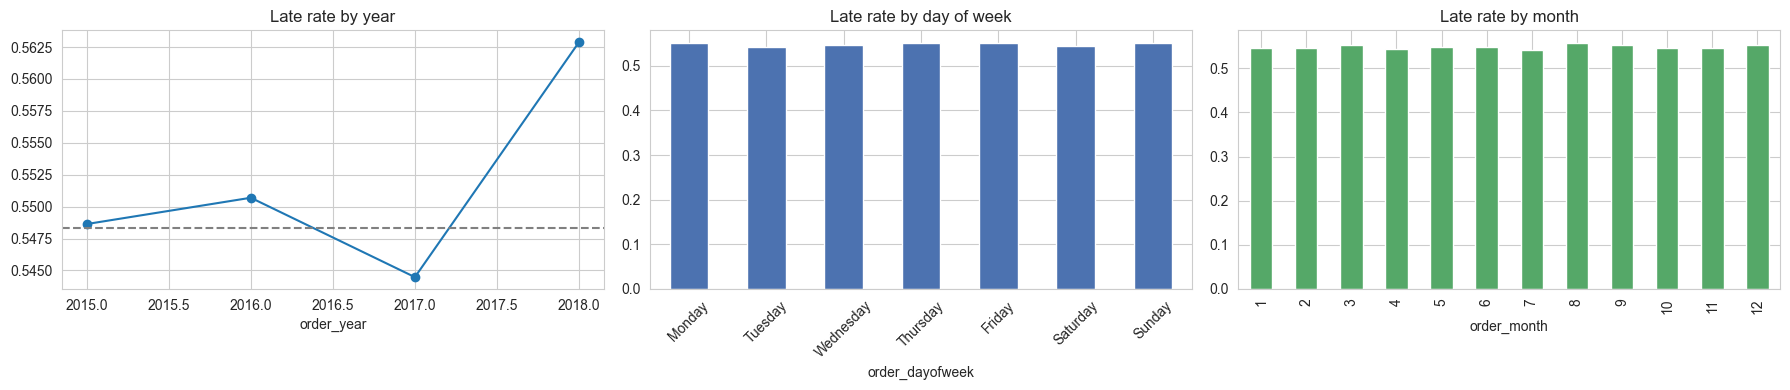

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

df.groupby('order_year')['Late_delivery_risk'].mean().plot(kind='line', marker='o', ax=ax[0])
ax[0].set_title('Late rate by year')
ax[0].axhline(df['Late_delivery_risk'].mean(), color='gray', linestyle='--')

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df.groupby('order_dayofweek')['Late_delivery_risk'].mean().reindex(dow_order).plot(kind='bar', ax=ax[1], color='#4C72B0')
ax[1].set_title('Late rate by day of week')
ax[1].tick_params(axis='x', rotation=45)

df.groupby('order_month')['Late_delivery_risk'].mean().plot(kind='bar', ax=ax[2], color='#55A868')
ax[2].set_title('Late rate by month')

plt.tight_layout()
plt.show()


**What we found:**

- **Date range: January 2015 to January 2018.** The 2018 slice is very thin - only 2,123 orders (a single month) vs. ~62,500–63,000 in each of 2015/2016 and 53,196 in 2017.
- **Late rate is stable year over year**: 54.86% (2015), 55.07% (2016), 54.45% (2017), 56.29% (2018, tiny sample) — all within a ~2pp band. No meaningful drift.
- **Day of week and month show essentially no variation** - both flat around 53–55%. Calendar based features are unlikely to add much predictive value on their own.

**Implication for the train/test split decision:** this finding cuts both ways. Stability across years weakens the "drift" argument for chronological splitting - but the thin, singlem onth 2018 tail makes a **naive calendar year split (train 2015–17, test 2018) a poor choice regardless**, since that test set would be too small and seasonally narrow (January only) to be representative.

**Decision, logged:** use a **proportion based chronological split** - sort by order date, take the most recent ~15–20% of orders as the test set (spanning roughly mid 2017 through January 2018), rather than a strict calendar year cutoff. This preserves the "test on the future, not a random shuffle" principle central to our leakage prevention design, while avoiding an unreasonably small test set.


## 8. Shipping mode and product category patterns

Late delivery rate by Shipping Mode:


,mean,count
Shipping Mode,,
First Class,0.953225,27814
Second Class,0.766328,35216
Same Day,0.457430,9737
Standard Class,0.380717,107752


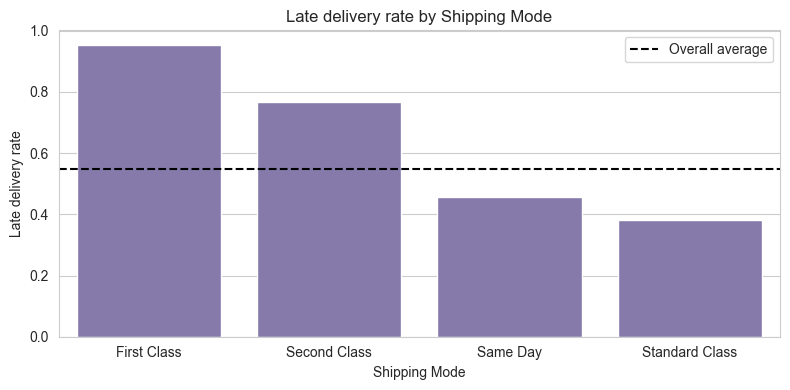

In [22]:
shipping_delay = df.groupby('Shipping Mode')['Late_delivery_risk'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Late delivery rate by Shipping Mode:")
display(shipping_delay)

plt.figure(figsize=(8, 4))
sns.barplot(x=shipping_delay.index, y=shipping_delay['mean'], color='#8172B2')
plt.axhline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.ylabel('Late delivery rate')
plt.title('Late delivery rate by Shipping Mode')
plt.legend()
plt.tight_layout()
plt.show()


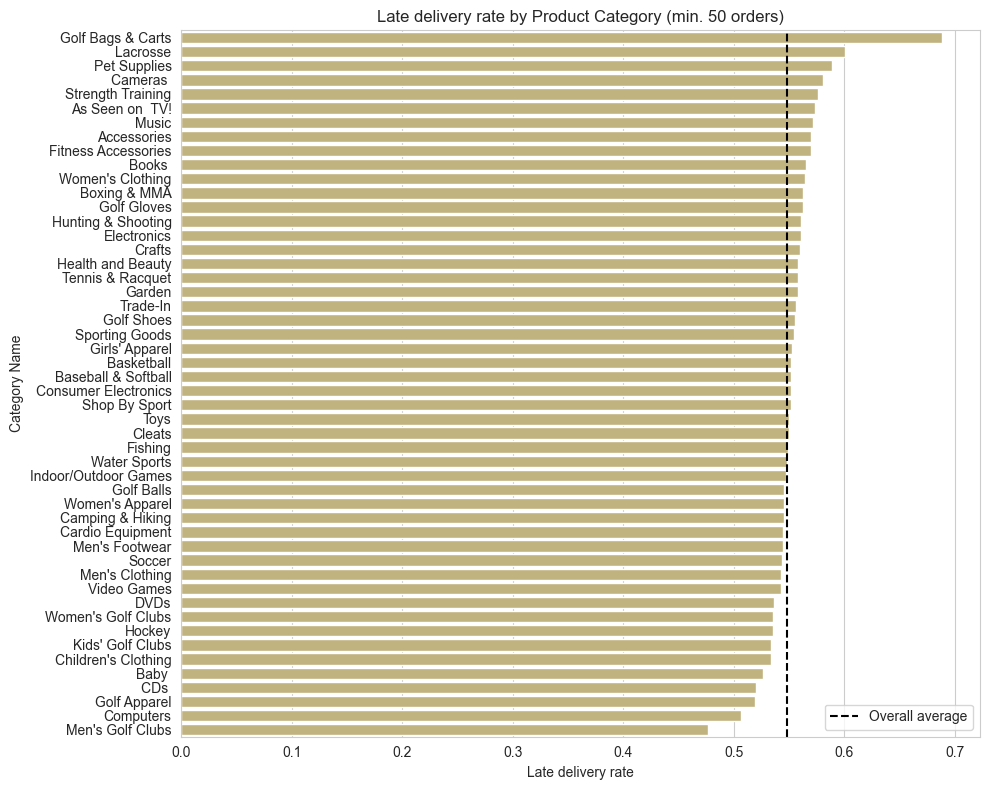

In [23]:
category_delay = df.groupby('Category Name')['Late_delivery_risk'].agg(['mean', 'count']).reset_index()
category_delay.columns = ['Category Name', 'late_rate', 'n_orders']
category_delay = category_delay[category_delay['n_orders'] >= 50].sort_values('late_rate', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=category_delay, y='Category Name', x='late_rate', color='#CCB974')
plt.axvline(df['Late_delivery_risk'].mean(), color='black', linestyle='--', label='Overall average')
plt.xlabel('Late delivery rate')
plt.title('Late delivery rate by Product Category (min. 50 orders)')
plt.legend()
plt.tight_layout()
plt.show()


**What we found:**

**Shipping Mode is, by a wide margin, the strongest signal found anywhere in this EDA:**

| Shipping Mode | Late rate | n orders |
|---|---|---|
| First Class | **95.32%** | 27,814 |
| Second Class | 76.63% | 35,216 |
| Same Day | 45.74% | 9,737 |
| Standard Class | 38.07% | 107,752 |

A **57 percentage point spread** - far wider than region (9pp) or even country (30pp). **Likely explanation:** faster shipping promises have much tighter scheduled delivery windows (`Days for shipment (scheduled)`), so even a small real world delay is far more likely to count as "late" against a 1 day promise than a 4 day one. This is a genuine, explainable operational pattern, not a data artifact.

**Implications:**
- This feature will likely dominate every model we build - it validates the rule based baseline (flagging by Shipping Mode/Region delay threshold) as a genuinely tough benchmark, not a token comparison.
- **Worth checking for near multicollinearity** between `Shipping Mode` and `Days for shipment (scheduled)` in Stage 3/4 before finalising the feature set, since a highly interpretable model (Logistic Regression) can behave oddly with near duplicate predictors.

**Product Category shows a moderate, more typical spread** - Golf Bags & Carts (~69%, highest) down to Men's Golf Clubs (~48%, lowest), roughly 21pp. A real but secondary signal.

**Decision to log:** Shipping Mode identified as the single strongest predictor in our EDA; multicollinearity check flagged for Stage 3/4.


## 9. Numeric feature distributions & outliers

In [24]:
numeric_cols_of_interest = ['Sales', 'Benefit per order', 'Order Item Quantity', 'Days for shipment (scheduled)']
numeric_cols_of_interest = [c for c in numeric_cols_of_interest if c in df.columns]

df[numeric_cols_of_interest].describe()


,Sales,Benefit per order,Order Item Quantity,Days for shipment (scheduled)
count,180519.000000,180519.000000,180519.000000,180519.000000
mean,203.772096,21.974989,2.127638,2.931847
std,132.273077,104.433526,1.453451,1.374449
min,9.990000,-4274.979980,1.000000,0.000000
25%,119.980003,7.000000,1.000000,2.000000
50%,199.919998,31.520000,1.000000,4.000000
75%,299.950012,64.800003,3.000000,4.000000
max,1999.989990,911.799988,5.000000,4.000000


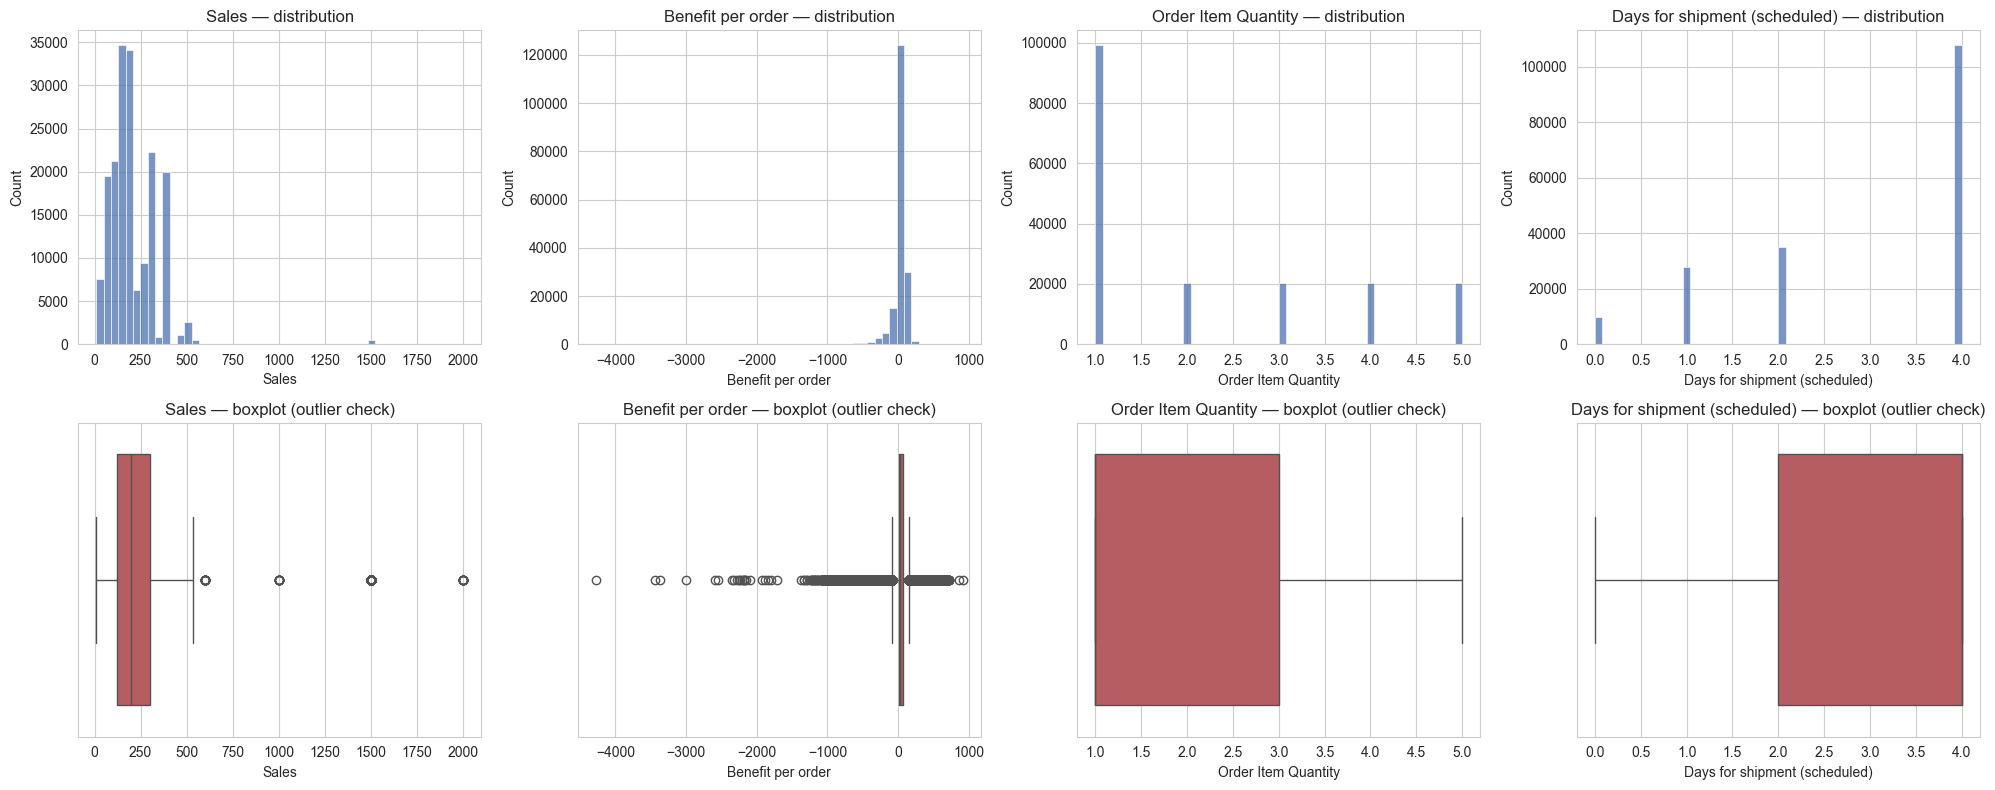

In [25]:
fig, axes = plt.subplots(2, len(numeric_cols_of_interest), figsize=(5*len(numeric_cols_of_interest), 8))

for i, col in enumerate(numeric_cols_of_interest):
    sns.histplot(df[col], bins=50, ax=axes[0, i], color='#4C72B0')
    axes[0, i].set_title(f'{col} — distribution')

    sns.boxplot(x=df[col], ax=axes[1, i], color='#C44E52')
    axes[1, i].set_title(f'{col} — boxplot (outlier check)')

plt.tight_layout()
plt.show()


In [26]:
for col in numeric_cols_of_interest:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    pct_outliers = n_outliers / len(df) * 100
    print(f"{col}: {n_outliers:,} outliers ({pct_outliers:.2f}%) outside [{lower:.2f}, {upper:.2f}]")


Sales: 488 outliers (0.27%) outside [-149.98, 569.91]
Benefit per order: 18,942 outliers (10.49%) outside [-79.70, 151.50]
Order Item Quantity: 0 outliers (0.00%) outside [-2.00, 6.00]
Days for shipment (scheduled): 0 outliers (0.00%) outside [-1.00, 7.00]


**What we found:**

| Column | Outliers (IQR) | Notes |
|---|---|---|
| `Sales` | 488 (0.27%) | Minimal — mildly right-skewed but not a real concern. |
| `Benefit per order` | **18,942 (10.49%)** | **Significant - needs a real Stage 3 decision.** |
| `Order Item Quantity` | 0 (0.00%) | Discrete, bounded 1–5, no treatment needed. |
| `Days for shipment (scheduled)` | 0 (0.00%) | Discrete, bounded 0–4, no treatment needed. |

**`Benefit per order` needs deliberate handling, and it matters specifically for our secondary lens.** Range is extreme: mean $21.97, but minimum **–$4,274.98**, maximum $911.80. Over 10% of orders fall outside the normal IQR range.

This is a real business event (large losses on individual orders), not a data error - but it directly affects our secondary lens's `risk × value` priority formula: does a large loss order count as "high value" and therefore high priority? Should `Sales` (always positive) be used instead of `Benefit per order` for the value term specifically to avoid sign confusion?

**Decision, logged:** (1) cap/winsorize `Benefit per order` for model training stability in Stage 3, and (2) explicitly define how negative profit orders are treated in the priority ranking formula - a business logic decision distinct from general data cleaning.

**Resolved separately: is using `Sales`/`Benefit per order` as classification model inputs a leakage risk?** No - both are genuinely known at order time, so there's no temporal leakage. The concern we raised early in project framing was more about whether these fields could act as a coincidental shortcut rather than a real driver of delivery risk; nothing in this EDA surfaced evidence of that. The real issue found is the outlier/data quality one above, which is a separate, resolved concern.


## 10. Final leakage field classification

In [27]:
leakage_classification = {
    'Delivery Status': 'excluded',
    'Late_delivery_risk': 'target',
    'Days for shipping (real)': 'excluded',
    'shipping date (DateOrders)': 'excluded',
    'Shipping Mode': 'safe',
    'Order Region': 'safe',
    'Order Country': 'safe',
    'Order City': 'safe',
    'Order State': 'safe',
    'Category Name': 'safe',
    'Category Id': 'safe',
    'Order Item Quantity': 'safe',
    'Sales': 'safe',
    'Benefit per order': 'safe',
    'Customer Segment': 'safe',
    'Type': 'safe',
    'Days for shipment (scheduled)': 'safe',
}

classification_df = pd.DataFrame(list(leakage_classification.items()), columns=['column', 'classification'])
classification_df


,column,classification
0,Delivery Status,excluded
1,Late_delivery_risk,target
2,Days for shipping (real),excluded
3,shipping date (DateOrders),excluded
4,Shipping Mode,safe
5,Order Region,safe
6,Order Country,safe
7,Order City,safe
8,Order State,safe
9,Category Name,safe


This table is the authoritative reference carried into Stage 3/4 - `Sales` and `Benefit per order` are confirmed **safe** (resolved above: known at order time, no evidence of a shortcut driven correlation, the only real issue was data quality, not leakage). 


## 11. EDA summary  

| # | Finding | Implication |
|---|---|---|
| 1 | Order line level data - 65,752 unique orders, 2.75 lines/order avg. Target consistent within an order; numeric fields vary across lines. | Aggregate to order level; per column aggregation rule logged. |
| 2 | Target audit clean - all `Delivery Status` categories map to one `Late_delivery_risk` value. `Shipping canceled` (4.3%) coded as 0. | Keep `Late_delivery_risk` as-is (evidence backed decision). |
| 3 | Class split 54.83% late / 45.17% not-late - close to balanced. | No imbalance handling needed; Recall prioritised for cost sensitivity, not imbalance. |
| 4 | Late rate stable 2015–2017; 2018 tail is thin (single month, 2,123 rows). Calendar effects (day/month) are flat. | Proportion based chronological split (last ~15–20% of orders), not a calendar year cutoff. |
| 5 | Country level delay rate spread (30pp) much wider than region level (9pp). Country names inconsistently localized. | Country level target encoding prioritised; standardise naming in Stage 3. |
| 6 | Shipping Mode spread is 57pp (First Class 95.3% vs. Standard Class 38.1%) - strongest signal found. Category spread is a moderate 21pp. | Check multicollinearity with `Days for shipment (scheduled)`; rule based baseline will be a genuinely tough benchmark. |
| 7 | `Benefit per order` has 10.49% outliers, min –$4,274.98. `Sales` and discrete fields are clean. | Cap/winsorize for modelling; explicit design decision needed for the priority formula's handling of negative-profit orders. |
| 8 | Leakage classification finalised - all planned features confirmed safe; `Sales`/`Benefit per order` cleared of leakage concern (data quality issue, not leakage). | Reference table for Stage 3/4 feature selection. |


